# Diseño interactivo de parámetros para funciones de recompensa

Este notebook es una herramienta de diseño, no un análisis de una corrida.

La pregunta principal es:

> ¿Qué geometría debe tener la recompensa para que el agente aprenda una secuencia física razonable?

La secuencia de diseño que se busca preservar es:

1. El lazo principal de cada variable se evalúa de forma local.
2. Las compuertas de la recompensa principal no mezclan lazos.
3. La coordinación es el único bloque donde aparece una combinación multi-lazo.
4. Los parámetros se juzgan por cómo ordenan comportamientos físicos, no por hacer más negativa la recompensa.
5. El usuario debe poder modificar parámetros y ver juntos: fenómeno, términos, compuertas, coordinación, recompensa total, acumulado y criterios de calibración.

El notebook funciona en dos modos:

- **modo manual**: editar diccionarios de parámetros y reejecutar celdas;
- **modo interactivo opcional**: si tu entorno tiene `ipywidgets`, aparece un panel con sliders.


## Sección 0 - Mapa del notebook y helpers mínimos

### Subcaja A: universo disponible

Este bloque carga librerías y define helpers pequeños.

Qué hace:
- define penalizaciones gaussianas;
- define compuertas exponenciales;
- define utilidades de mezcla de diccionarios y visualización;
- deja un fallback si `IPython.display` no está disponible.

Qué significan los parámetros:
- todavía no se fijan parámetros de reward;
- solo se construye el lenguaje matemático mínimo que usará el notebook.

Qué se debería buscar:
- funciones simples, visibles y reutilizables;
- nada de lógica escondida grande.

Cómo interpretar la salida:
- esta celda no genera decisiones; prepara el terreno.


In [1]:
from copy import deepcopy
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:
    def display(obj):
        print(obj)

    class Markdown(str):
        pass

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True


def gaussian_penalty(x, weight, scaled, setpoint=0.0):
    x = np.asarray(x, dtype=float)
    return -weight * (1.0 - np.exp(-scaled * (x - setpoint) ** 2))


def exp_gate(x, scaled, min_factor, max_factor, setpoint=0.0, invert=False):
    x = np.asarray(x, dtype=float)
    base = np.exp(-((np.abs(x - setpoint) / scaled) ** 2)) if scaled > 0 else np.zeros_like(x)
    if invert:
        base = 1.0 - base
    return np.clip(base, min_factor, max_factor)


def deep_update(base, override):
    out = deepcopy(base)
    for key, value in override.items():
        if isinstance(value, dict) and isinstance(out.get(key), dict):
            out[key] = deep_update(out[key], value)
        else:
            out[key] = value
    return out


def table_from_nested(mapping, index_name):
    return pd.DataFrame.from_dict(mapping, orient="index").reset_index(names=index_name)


### Subcaja B: configuración analítica

Este bloque define el mapa de secciones y la idea de salida reusable.

Qué hace:
- explicita qué objeto produce cada sección;
- sirve como guía para recorrer el notebook sin perder el hilo.

Qué significan los parámetros:
- `NOTEBOOK_FLOW` no controla el reward;
- describe la línea de desarrollo del análisis.

Qué se debería buscar:
- que cada sección alimente a la siguiente;
- que el diseño avance desde fenómeno hacia decisión, no al revés.

Cómo interpretar la salida:
- úsala como índice operativo del notebook.


In [2]:
NOTEBOOK_FLOW = pd.DataFrame([
    {"section": 0, "name": "Mapa y helpers", "reusable_output": "helpers matemáticos"},
    {"section": 1, "name": "Fenómeno sintético", "reusable_output": "behavior_profile_df"},
    {"section": 2, "name": "Parámetros editables", "reusable_output": "active_design_params"},
    {"section": 3, "name": "Evaluador total", "reusable_output": "loop_reward_df, global_reward_df"},
    {"section": 4, "name": "Dashboard conjunto", "reusable_output": "figuras integradas"},
    {"section": 5, "name": "Superficies de respuesta", "reusable_output": "surface_df"},
    {"section": 6, "name": "Barrido fenomenológico", "reusable_output": "sweep_decision_df"},
    {"section": 7, "name": "Panel interactivo", "reusable_output": "sliders opcionales"},
    {"section": 8, "name": "Ficha de propuesta", "reusable_output": "proposal_card"},
])

display(NOTEBOOK_FLOW)


,section,name,reusable_output
0,0,Mapa y helpers,helpers matemáticos
1,1,Fenómeno sintético,behavior_profile_df
2,2,Parámetros editables,active_design_params
3,3,Evaluador total,"loop_reward_df, global_reward_df"
4,4,Dashboard conjunto,figuras integradas
5,5,Superficies de respuesta,surface_df
6,6,Barrido fenomenológico,sweep_decision_df
7,7,Panel interactivo,sliders opcionales
8,8,Ficha de propuesta,proposal_card


### Subcaja C: salida

Este bloque fija el criterio de lectura.

Qué hace:
- deja explícito qué cuenta como coherencia y qué cuenta como anomalía;
- evita que el diseño se reduzca a “subir o bajar pesos”.

Qué significan los parámetros:
- son criterios conceptuales, no valores finales.

Qué se debería buscar:
- una recompensa que preserve una escalera de aprendizaje;
- una recompensa total que acompañe el fenómeno físico.

Cómo interpretar la salida:
- si un parámetro mejora una métrica pero rompe un criterio, no es un buen parámetro.


In [3]:
DESIGN_CRITERIA = pd.DataFrame([
    {"criterion": "Independencia local", "coherent": "principal y compuertas usan solo métricas del mismo lazo", "anomaly": "una compuerta de un lazo usa el error de otro"},
    {"criterion": "Escalera de aprendizaje", "coherent": "captura parcial es mejor que fallo corto", "anomaly": "castigar escape del carro hace peor capturar parcialmente"},
    {"criterion": "Recentrado", "coherent": "captura limpia supera captura con deriva", "anomaly": "sobrevivir con carro lejos recibe reward parecido al caso limpio"},
    {"criterion": "Coordinación", "coherent": "el bonus aparece al reducir potencial global", "anomaly": "hay bonus alto sin mejora física"},
    {"criterion": "Esfuerzo", "coherent": "se penaliza exceso sin impedir maniobras necesarias", "anomaly": "el agente evita actuar porque actuar es demasiado caro"},
])

display(DESIGN_CRITERIA)


,criterion,coherent,anomaly
0,Independencia local,principal y compuertas usan solo métricas del ...,una compuerta de un lazo usa el error de otro
1,Escalera de aprendizaje,captura parcial es mejor que fallo corto,castigar escape del carro hace peor capturar p...
2,Recentrado,captura limpia supera captura con deriva,sobrevivir con carro lejos recibe reward parec...
3,Coordinación,el bonus aparece al reducir potencial global,hay bonus alto sin mejora física
4,Esfuerzo,se penaliza exceso sin impedir maniobras neces...,el agente evita actuar porque actuar es demasi...


## Sección 1 - Fenómeno físico sintético editable

### Subcaja A: universo disponible

Este bloque define comportamientos físicos sintéticos.

Qué hace:
- construye trayectorias de ángulo, posición de carro, velocidades y esfuerzo;
- transforma esas trayectorias en métricas `L_e`, `L_edot` y `L_u`;
- no usa resultados de simulación.

Qué significan los parámetros:
- `capture_rate_*`: rapidez con que cae el error angular;
- `cart_drift_*`: deriva del carro;
- `effort_*`: esfuerzo relativo del control;
- `*_scale`: normalización fenomenológica para convertir variables físicas a métricas.

Qué se debería buscar:
- perfiles suficientemente distintos para probar decisiones de diseño;
- perfiles interpretables físicamente.

Cómo interpretar la salida:
- estas trayectorias son un laboratorio de diseño: si el reward falla aquí, no conviene llevarlo a una corrida.


In [4]:
# ----------------------------
# Configuración Sección 1
# ----------------------------
TIME_CONFIG = {
    "t_end": 5.0,
    "n_points": 260,
}

PHYSICAL_SCALES = {
    "angle_scale": 0.55,
    "cart_scale": 5.0,
    "angular_velocity_scale": 2.5,
    "cart_velocity_scale": 4.0,
    "effort_scale": 1.0,
}

PROFILE_PARAMS = {
    "A_clean_capture": {
        "capture_rate": 1.65,
        "angle_floor": 0.015,
        "cart_drift": 0.55,
        "cart_return": 0.25,
        "effort": 0.18,
    },
    "B_survive_drift": {
        "capture_rate": 1.10,
        "angle_floor": 0.055,
        "cart_drift": 2.8,
        "cart_return": 0.00,
        "effort": 0.24,
    },
    "C_capture_runaway": {
        "capture_rate": 0.95,
        "angle_floor": 0.085,
        "cart_drift": 5.0,
        "cart_return": 0.00,
        "effort": 0.28,
    },
    "E_short_bad": {
        "capture_rate": -0.20,
        "angle_floor": 0.65,
        "cart_drift": 1.2,
        "cart_return": 0.00,
        "effort": 0.65,
    },
}


### Subcaja B: configuración analítica

Este bloque contiene la función que genera perfiles.

Qué hace:
- calcula estado físico sintético;
- calcula derivadas con `np.gradient`;
- convierte estado físico a métricas normalizadas;
- conserva todo en una tabla larga por `behavior`, `loop` y tiempo.

Qué significan los parámetros:
- `behavior`: clase fenomenológica;
- `loop`: lazo al que pertenece la métrica;
- `L_e`, `L_edot`, `L_u`: métricas procesadas comparables con reward.

Qué se debería buscar:
- que cada perfil tenga sentido como historia física;
- que los perfiles puedan modificarse desde `PROFILE_PARAMS`.

Cómo interpretar la salida:
- `behavior_profile_df` será la base común para recompensa, coordinación, dashboards y criterios.


In [5]:
def metric_abs(value, scale):
    return np.clip(np.abs(value) / scale, 0.0, 1.0)


def build_behavior_profiles(time_config, profile_params, physical_scales):
    t = np.linspace(0.0, time_config["t_end"], time_config["n_points"])
    dt = t[1] - t[0]
    frames = []

    for behavior, cfg in profile_params.items():
        if behavior == "E_short_bad":
            angle = 0.16 + 0.52 * (t / t.max()) ** 1.1 + 0.05 * np.sin(4 * np.pi * t / t.max())
        else:
            angle = 0.16 * np.exp(-cfg["capture_rate"] * t) + cfg["angle_floor"]

        cart = cfg["cart_drift"] * (t / t.max()) ** 1.35
        if cfg["cart_return"] > 0:
            cart = cart * np.exp(-cfg["cart_return"] * t)

        angular_velocity = np.gradient(angle, dt)
        cart_velocity = np.gradient(cart, dt)
        effort = cfg["effort"] * (0.55 + 0.45 * np.exp(-0.6 * t))

        raw = pd.DataFrame({
            "t": t,
            "behavior": behavior,
            "pendulum_angle_raw": angle,
            "cart_position_raw": cart,
            "pendulum_velocity_raw": angular_velocity,
            "cart_velocity_raw": cart_velocity,
            "u_total_raw": effort,
        })

        pendulum = pd.DataFrame({
            "t": t,
            "behavior": behavior,
            "loop": "pendulum_angle",
            "raw_value": angle,
            "raw_velocity": angular_velocity,
            "L_e": metric_abs(angle, physical_scales["angle_scale"]),
            "L_edot": metric_abs(angular_velocity, physical_scales["angular_velocity_scale"]),
            "L_u": metric_abs(effort, physical_scales["effort_scale"]),
        })

        cart_loop = pd.DataFrame({
            "t": t,
            "behavior": behavior,
            "loop": "cart_position",
            "raw_value": cart,
            "raw_velocity": cart_velocity,
            "L_e": metric_abs(cart, physical_scales["cart_scale"]),
            "L_edot": metric_abs(cart_velocity, physical_scales["cart_velocity_scale"]),
            "L_u": metric_abs(effort, physical_scales["effort_scale"]),
        })

        merged = pd.concat([pendulum, cart_loop], ignore_index=True)
        for col in ["pendulum_angle_raw", "cart_position_raw", "pendulum_velocity_raw", "cart_velocity_raw", "u_total_raw"]:
            merged[col] = np.tile(raw[col].to_numpy(), 2)
        frames.append(merged)

    return pd.concat(frames, ignore_index=True)


behavior_profile_df = build_behavior_profiles(TIME_CONFIG, PROFILE_PARAMS, PHYSICAL_SCALES)
display(behavior_profile_df.head())


,t,behavior,loop,raw_value,raw_velocity,L_e,L_edot,L_u,pendulum_angle_raw,cart_position_raw,pendulum_velocity_raw,cart_velocity_raw,u_total_raw
0,0.000000,A_clean_capture,pendulum_angle,0.175000,-0.259840,0.318182,0.103936,0.180000,0.175000,0.000000,-0.259840,0.015655,0.180000
1,0.019305,A_clean_capture,pendulum_angle,0.169984,-0.255767,0.309061,0.102307,0.179067,0.169984,0.000302,-0.255767,0.019857,0.179067
2,0.038610,A_clean_capture,pendulum_angle,0.165125,-0.247748,0.300227,0.099099,0.178145,0.165125,0.000767,-0.247748,0.026334,0.178145
3,0.057915,A_clean_capture,pendulum_angle,0.160418,-0.239981,0.291670,0.095992,0.177234,0.160418,0.001319,-0.239981,0.030274,0.177234
4,0.077220,A_clean_capture,pendulum_angle,0.155859,-0.232457,0.283380,0.092983,0.176333,0.155859,0.001936,-0.232457,0.033266,0.176333


### Subcaja C: salida

Este bloque visualiza el fenómeno antes de calcular recompensa.

Qué hace:
- grafica variables físicas crudas;
- grafica métricas procesadas por lazo;
- deja una tabla resumen por comportamiento.

Qué significan los parámetros:
- `SECTION_1_BEHAVIORS_TO_SHOW`: comportamientos visibles.

Qué se debería buscar:
- que el comportamiento `A` represente captura limpia;
- que `B` sobreviva con deriva;
- que `C` capture parcialmente pero escape;
- que `E` sea claramente malo.

Cómo interpretar la salida:
- si el fenómeno sintético no representa lo que quieres calibrar, ajusta `PROFILE_PARAMS` antes de tocar reward.


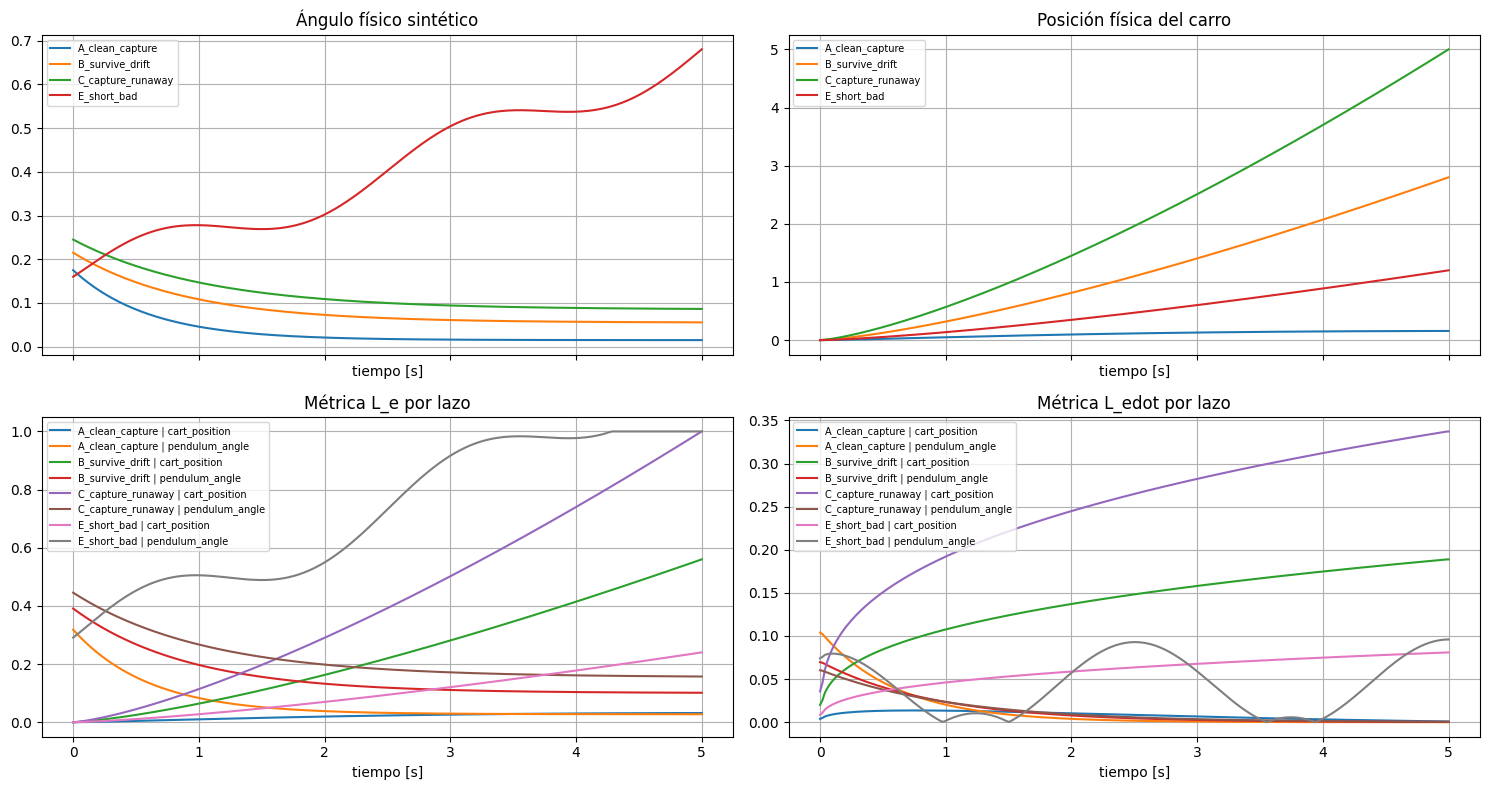

,behavior,loop,L_e_mean,L_e_final,L_edot_mean,L_u_mean,raw_abs_mean
0,A_clean_capture,cart_position,0.0203,0.0315,0.0079,0.1247,0.1013
1,A_clean_capture,pendulum_angle,0.0630,0.0273,0.0129,0.1247,0.0346
2,B_survive_drift,cart_position,0.2385,0.5600,0.1399,0.1663,1.1923
3,B_survive_drift,pendulum_angle,0.1530,0.1012,0.0128,0.1663,0.0842
4,C_capture_runaway,cart_position,0.4258,1.0000,0.2498,0.1940,2.1291
5,C_capture_runaway,pendulum_angle,0.2156,0.1571,0.0128,0.1940,0.1186
6,E_short_bad,cart_position,0.1022,0.2400,0.0599,0.4504,0.5110
7,E_short_bad,pendulum_angle,0.7264,1.0000,0.0438,0.4504,0.4077


In [6]:
SECTION_1_BEHAVIORS_TO_SHOW = list(PROFILE_PARAMS.keys())

plot_profile_df = behavior_profile_df[behavior_profile_df["behavior"].isin(SECTION_1_BEHAVIORS_TO_SHOW)].copy()
raw_once_df = plot_profile_df.drop_duplicates(["behavior", "t"])

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

for behavior, local_df in raw_once_df.groupby("behavior"):
    axes[0, 0].plot(local_df["t"], local_df["pendulum_angle_raw"], label=behavior)
    axes[0, 1].plot(local_df["t"], local_df["cart_position_raw"], label=behavior)

for (behavior, loop), local_df in plot_profile_df.groupby(["behavior", "loop"]):
    axes[1, 0].plot(local_df["t"], local_df["L_e"], label=f"{behavior} | {loop}")
    axes[1, 1].plot(local_df["t"], local_df["L_edot"], label=f"{behavior} | {loop}")

axes[0, 0].set_title("Ángulo físico sintético")
axes[0, 1].set_title("Posición física del carro")
axes[1, 0].set_title("Métrica L_e por lazo")
axes[1, 1].set_title("Métrica L_edot por lazo")

for ax in axes.ravel():
    ax.set_xlabel("tiempo [s]")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

profile_summary_df = (
    behavior_profile_df
    .groupby(["behavior", "loop"])
    .agg(
        L_e_mean=("L_e", "mean"),
        L_e_final=("L_e", "last"),
        L_edot_mean=("L_edot", "mean"),
        L_u_mean=("L_u", "mean"),
        raw_abs_mean=("raw_value", lambda s: float(np.mean(np.abs(s)))),
    )
    .reset_index()
)
display(profile_summary_df.round(4))


## Sección 2 - Parámetros de recompensa como objeto editable

### Subcaja A: universo disponible

Este bloque define los parámetros de reward como un objeto editable.

Qué hace:
- separa recompensa principal, compuertas y coordinación;
- crea candidatos para comparar decisiones;
- mantiene explícito el contrato de no mezclar lazos en la principal.

Qué significan los parámetros:
- `features`: peso, escala y setpoint de cada término;
- `gates`: compuertas por término y lazo;
- `coordination`: diferencia de potencial global.

Qué se debería buscar:
- cambios pequeños y localizados;
- coordinación suficiente pero no dominante.

Cómo interpretar la salida:
- este objeto es la fuente de verdad para todos los cálculos posteriores.


In [7]:
BASE_REWARD_PARAMS = {
    "features": {
        "L_e":    {"weight": 0.72,  "scaled": 5.2, "setpoint": 0.0},
        "L_edot": {"weight": 0.22,  "scaled": 2.2, "setpoint": 0.0},
        "L_I":    {"weight": 0.0,   "scaled": 1.0, "setpoint": 0.0},
        "L_u":    {"weight": 0.035, "scaled": 0.7, "setpoint": 0.0},
    },
    "gates": {
        "L_e": {
            "pendulum_angle": {"source_feature": "L_e", "scaled": 1.00, "min_factor": 1.000, "max_factor": 1.00, "invert": False},
            "cart_position":  {"source_feature": "L_e", "scaled": 0.45, "min_factor": 0.050, "max_factor": 0.30, "invert": True},
        },
        "L_edot": {
            "pendulum_angle": {"source_feature": "L_e", "scaled": 0.25, "min_factor": 0.180, "max_factor": 0.95, "invert": False},
            "cart_position":  {"source_feature": "L_e", "scaled": 0.55, "min_factor": 0.020, "max_factor": 0.20, "invert": True},
        },
        "L_u": {
            "pendulum_angle": {"source_feature": "L_e", "scaled": 0.22, "min_factor": 0.020, "max_factor": 0.32, "invert": False},
            "cart_position":  {"source_feature": "L_e", "scaled": 0.30, "min_factor": 0.005, "max_factor": 0.16, "invert": False},
        },
    },
    "coordination": {
        "global_weight": 12.0,
        "progress_clip_max": 0.04,
        "potential_weights": {
            "L_e":    {"pendulum_angle": 0.70, "cart_position": 0.15},
            "L_edot": {"pendulum_angle": 0.22, "cart_position": 0.04},
        },
    },
}

CANDIDATE_OVERRIDES = {
    "base_soft_recenter": {},
    "more_cart_recenter": {
        "gates": {
            "L_e": {"cart_position": {"max_factor": 0.34}},
            "L_edot": {"cart_position": {"max_factor": 0.23}},
        }
    },
    "less_effort_penalty": {
        "features": {"L_u": {"weight": 0.025}}
    },
    "strong_coordination": {
        "coordination": {"global_weight": 16.0}
    },
}

def build_reward_params(candidate_name="base_soft_recenter", manual_override=None):
    params = deep_update(BASE_REWARD_PARAMS, CANDIDATE_OVERRIDES.get(candidate_name, {}))
    if manual_override:
        params = deep_update(params, manual_override)
    return params


### Subcaja B: configuración analítica

Este bloque es el panel manual principal.

Qué hace:
- selecciona un candidato;
- permite sobreescribir parámetros puntuales;
- reconstruye `active_design_params`.

Qué significan los parámetros:
- `ACTIVE_CANDIDATE`: candidato base;
- `MANUAL_REWARD_OVERRIDE`: cambios locales que quieres probar.

Qué se debería buscar:
- tocar pocas perillas a la vez;
- mirar efecto conjunto en el dashboard antes de decidir.

Cómo interpretar la salida:
- si quieres modificar parámetros sin widgets, este es el lugar.


In [8]:
# ----------------------------
# Panel manual de diseño
# ----------------------------
ACTIVE_CANDIDATE = "base_soft_recenter"

MANUAL_REWARD_OVERRIDE = {
    # Ejemplos:
    # "features": {"L_u": {"weight": 0.030}},
    # "gates": {"L_e": {"cart_position": {"max_factor": 0.32}}},
    # "coordination": {"global_weight": 14.0},
}

active_design_params = build_reward_params(ACTIVE_CANDIDATE, MANUAL_REWARD_OVERRIDE)
print(json.dumps(active_design_params, indent=2, ensure_ascii=False))


{
  "features": {
    "L_e": {
      "weight": 0.72,
      "scaled": 5.2,
      "setpoint": 0.0
    },
    "L_edot": {
      "weight": 0.22,
      "scaled": 2.2,
      "setpoint": 0.0
    },
    "L_I": {
      "weight": 0.0,
      "scaled": 1.0,
      "setpoint": 0.0
    },
    "L_u": {
      "weight": 0.035,
      "scaled": 0.7,
      "setpoint": 0.0
    }
  },
  "gates": {
    "L_e": {
      "pendulum_angle": {
        "source_feature": "L_e",
        "scaled": 1.0,
        "min_factor": 1.0,
        "max_factor": 1.0,
        "invert": false
      },
      "cart_position": {
        "source_feature": "L_e",
        "scaled": 0.45,
        "min_factor": 0.05,
        "max_factor": 0.3,
        "invert": true
      }
    },
    "L_edot": {
      "pendulum_angle": {
        "source_feature": "L_e",
        "scaled": 0.25,
        "min_factor": 0.18,
        "max_factor": 0.95,
        "invert": false
      },
      "cart_position": {
        "source_feature": "L_e",
        "scaled": 0

### Subcaja C: salida

Este bloque audita el contrato de diseño.

Qué hace:
- transforma parámetros en tablas;
- explicita que las compuertas de principal son locales;
- deja tablas reutilizables para revisar cambios.

Qué significan los parámetros:
- cada fila de compuerta indica término, lazo y fuente.

Qué se debería buscar:
- `cross_loop_dependency = False` en todas las compuertas principales;
- pesos de potencial concentrados en coordinación.

Cómo interpretar la salida:
- si aparece mezcla de lazos en principal, el diseño pierde portabilidad.


In [9]:
feature_table_df = table_from_nested(active_design_params["features"], "feature")

gate_rows = []
for feature, per_loop in active_design_params["gates"].items():
    for loop, cfg in per_loop.items():
        gate_rows.append({"feature": feature, "loop": loop, **cfg, "cross_loop_dependency": False})
gate_table_df = pd.DataFrame(gate_rows)

coord_rows = []
for feature, per_loop in active_design_params["coordination"]["potential_weights"].items():
    for loop, weight in per_loop.items():
        coord_rows.append({"feature": feature, "loop": loop, "potential_weight": weight})
coord_table_df = pd.DataFrame(coord_rows)

display(feature_table_df)
display(gate_table_df)
display(coord_table_df)


,feature,weight,scaled,setpoint
0,L_e,0.720,5.2,0.0
1,L_edot,0.220,2.2,0.0
2,L_I,0.000,1.0,0.0
3,L_u,0.035,0.7,0.0


,feature,loop,source_feature,scaled,min_factor,max_factor,invert,cross_loop_dependency
0,L_e,pendulum_angle,L_e,1.00,1.000,1.00,False,False
1,L_e,cart_position,L_e,0.45,0.050,0.30,True,False
2,L_edot,pendulum_angle,L_e,0.25,0.180,0.95,False,False
3,L_edot,cart_position,L_e,0.55,0.020,0.20,True,False
4,L_u,pendulum_angle,L_e,0.22,0.020,0.32,False,False
5,L_u,cart_position,L_e,0.30,0.005,0.16,False,False


,feature,loop,potential_weight
0,L_e,pendulum_angle,0.70
1,L_e,cart_position,0.15
2,L_edot,pendulum_angle,0.22
3,L_edot,cart_position,0.04


## Sección 3 - Evaluador integrado de recompensa total

### Subcaja A: universo disponible

Este bloque integra fenómeno, principal, compuertas y coordinación.

Qué hace:
- evalúa contribuciones principales por lazo;
- calcula el potencial coordinativo;
- calcula progreso positivo del potencial;
- suma principal y coordinación para obtener recompensa total.

Qué significan los parámetros:
- `principal_reward`: suma local de los lazos;
- `coordination_reward`: bonus por reducción de potencial;
- `global_reward`: recompensa total del intervalo sintético.

Qué se debería buscar:
- que la recompensa total explique el fenómeno;
- que la coordinación ayude al progreso, pero no tape errores persistentes.

Cómo interpretar la salida:
- esta es la pieza central del notebook.


In [12]:
def evaluate_loop_with_design(loop_df, params, loop_name):
    out = loop_df.copy()
    total = np.zeros(len(out), dtype=float)

    for feature, cfg in params["features"].items():
        if feature == "L_I":
            continue

        values = out[feature].to_numpy(dtype=float)
        gate_cfg = params["gates"].get(feature, {}).get(loop_name)
        gate = np.ones(len(out), dtype=float)
        if gate_cfg is not None:
            gate_source = out[gate_cfg["source_feature"]].to_numpy(dtype=float)
            gate = exp_gate(
                gate_source,
                gate_cfg["scaled"],
                gate_cfg["min_factor"],
                gate_cfg["max_factor"],
                invert=gate_cfg.get("invert", False),
            )

        contribution = gate * gaussian_penalty(values, **cfg)
        out[f"gate_{feature}"] = gate
        out[f"reward_{feature}"] = contribution
        total += contribution

    out["principal_loop_reward"] = total
    return out


def evaluate_reward_design(profile_df, params):
    loop_parts = []
    for (behavior, loop_name), loop_df in profile_df.groupby(["behavior", "loop"], sort=False):
        loop_parts.append(evaluate_loop_with_design(loop_df, params, loop_name))
    loop_reward_df = pd.concat(loop_parts, ignore_index=True)

    principal_df = (
        loop_reward_df
        .groupby(["behavior", "t"])
        .agg(principal_reward=("principal_loop_reward", "sum"))
        .reset_index()
    )

    wide_metrics = profile_df.pivot_table(
        index=["behavior", "t"],
        columns="loop",
        values=["L_e", "L_edot", "L_u"],
        aggfunc="first",
    )
    wide_metrics.columns = [f"{feature}_{loop}" for feature, loop in wide_metrics.columns]
    wide_metrics = wide_metrics.reset_index()

    coord = params["coordination"]
    wide_metrics["coordination_potential"] = 0.0
    for feature, per_loop in coord["potential_weights"].items():
        for loop, weight in per_loop.items():
            wide_metrics["coordination_potential"] += weight * wide_metrics[f"{feature}_{loop}"]

    wide_metrics["coordination_progress"] = -wide_metrics.groupby("behavior")["coordination_potential"].diff()
    wide_metrics["coordination_progress"] = wide_metrics["coordination_progress"].clip(lower=0.0, upper=coord["progress_clip_max"]).fillna(0.0)
    wide_metrics["coordination_reward"] = coord["global_weight"] * wide_metrics["coordination_progress"]

    global_reward_df = principal_df.merge(
        wide_metrics[["behavior", "t", "coordination_potential", "coordination_progress", "coordination_reward"]],
        on=["behavior", "t"],
        how="left",
    )
    global_reward_df["global_reward"] = global_reward_df["principal_reward"] + global_reward_df["coordination_reward"]
    global_reward_df["cumulative_global_reward"] = global_reward_df.groupby("behavior")["global_reward"].cumsum()

    return loop_reward_df, global_reward_df


### Subcaja B: configuración analítica

Este bloque ejecuta el evaluador con el fenómeno y los parámetros activos.

Qué hace:
- produce `loop_reward_df`;
- produce `global_reward_df`;
- resume reward por comportamiento.

Qué significan los parámetros:
- usa `behavior_profile_df` y `active_design_params`.

Qué se debería buscar:
- orden fenomenológico razonable;
- diferencias explicables por componentes.

Cómo interpretar la salida:
- si el resumen contradice el fenómeno, vuelve a Sección 2 o Sección 1.


In [13]:
loop_reward_df, global_reward_df = evaluate_reward_design(behavior_profile_df, active_design_params)

behavior_reward_summary_df = (
    global_reward_df
    .groupby("behavior")
    .agg(
        principal_mean=("principal_reward", "mean"),
        coordination_mean=("coordination_reward", "mean"),
        global_mean=("global_reward", "mean"),
        global_total=("global_reward", "sum"),
        final_cumulative=("cumulative_global_reward", "last"),
        potential_start=("coordination_potential", "first"),
        potential_end=("coordination_potential", "last"),
    )
    .reset_index()
)

display(behavior_reward_summary_df.round(4))


,behavior,principal_mean,coordination_mean,global_mean,global_total,final_cumulative,potential_start,potential_end
0,A_clean_capture,-0.0270,0.0102,-0.0168,-4.3656,-4.3656,0.2457,0.0239
1,B_survive_drift,-0.1527,0.0077,-0.1450,-37.6902,-37.6902,0.2898,0.1625
2,C_capture_runaway,-0.2741,0.0061,-0.2680,-69.6707,-69.6707,0.3265,0.2736
3,E_short_bad,-0.6212,0.0005,-0.6207,-161.3717,-161.3717,0.2203,0.7604


### Subcaja C: salida

Este bloque genera una tabla de contribuciones por lazo y término.

Qué hace:
- resume cuánto aporta cada término;
- separa péndulo y carro;
- permite detectar dominancias no deseadas.

Qué significan los parámetros:
- `reward_L_e`, `reward_L_edot`, `reward_L_u`: contribuciones principales;
- `principal_loop_reward`: suma del lazo.

Qué se debería buscar:
- que el péndulo domine cuando el ángulo es el fenómeno crítico;
- que el carro aparezca cuando hay deriva;
- que `L_u` no bloquee maniobras necesarias.

Cómo interpretar la salida:
- si una contribución explica casi todo, el diseño quizá dejó de ser balanceado.


In [14]:
component_cols = ["reward_L_e", "reward_L_edot", "reward_L_u", "principal_loop_reward"]
component_summary_df = (
    loop_reward_df
    .groupby(["behavior", "loop"])[component_cols]
    .mean()
    .reset_index()
)

display(component_summary_df.round(4))


,behavior,loop,reward_L_e,reward_L_edot,reward_L_u,principal_loop_reward
0,A_clean_capture,cart_position,-0.0001,-0.0000,-0.0001,-0.0002
1,A_clean_capture,pendulum_angle,-0.0266,-0.0002,-0.0001,-0.0269
2,B_survive_drift,cart_position,-0.0588,-0.0015,-0.0001,-0.0604
3,B_survive_drift,pendulum_angle,-0.0920,-0.0001,-0.0002,-0.0923
4,C_capture_runaway,cart_position,-0.1088,-0.0053,-0.0001,-0.1142
5,C_capture_runaway,pendulum_angle,-0.1596,-0.0000,-0.0002,-0.1599
6,E_short_bad,cart_position,-0.0080,-0.0001,-0.0008,-0.0089
7,E_short_bad,pendulum_angle,-0.6119,-0.0003,-0.0001,-0.6123


## Sección 4 - Dashboard conjunto fenómeno-recompensa

### Subcaja A: universo disponible

Este bloque define un dashboard integrado.

Qué hace:
- muestra fenómeno físico, métricas, compuertas, componentes, recompensa total y acumulado;
- usa una sola función para que el modo manual y el modo interactivo vean lo mismo.

Qué significan los parámetros:
- `selected_behavior`: comportamiento que se inspecciona en detalle;
- `params`: parámetros de reward evaluados;
- `profile_df`: fenómeno sintético.

Qué se debería buscar:
- coherencia visual entre mejora física y reward;
- explicación de por qué una trayectoria recibe más o menos recompensa.

Cómo interpretar la salida:
- este panel es la herramienta principal de diseño.


In [15]:
def plot_design_dashboard(profile_df, params, selected_behavior="C_capture_runaway"):
    loop_df, global_df = evaluate_reward_design(profile_df, params)
    local_raw = profile_df.drop_duplicates(["behavior", "t"])
    local_loop = loop_df[loop_df["behavior"] == selected_behavior]
    local_global = global_df[global_df["behavior"] == selected_behavior]

    summary = (
        global_df
        .groupby("behavior")
        .agg(global_mean=("global_reward", "mean"), global_total=("global_reward", "sum"), coordination_mean=("coordination_reward", "mean"))
        .reset_index()
        .sort_values("global_mean", ascending=False)
    )

    fig, axes = plt.subplots(3, 2, figsize=(16, 13))

    for behavior, df in local_raw.groupby("behavior"):
        axes[0, 0].plot(df["t"], df["pendulum_angle_raw"], label=behavior)
        axes[0, 1].plot(df["t"], df["cart_position_raw"], label=behavior)
    axes[0, 0].set_title("Fenómeno: ángulo")
    axes[0, 1].set_title("Fenómeno: posición del carro")

    for loop, df in local_loop.groupby("loop"):
        axes[1, 0].plot(df["t"], df["L_e"], label=f"L_e | {loop}")
        axes[1, 0].plot(df["t"], df["L_edot"], linestyle="--", label=f"L_edot | {loop}")
        axes[1, 1].plot(df["t"], df["principal_loop_reward"], label=f"principal | {loop}")
    axes[1, 0].set_title(f"Métricas procesadas | {selected_behavior}")
    axes[1, 1].set_title(f"Reward principal por lazo | {selected_behavior}")

    axes[2, 0].plot(local_global["t"], local_global["principal_reward"], label="principal")
    axes[2, 0].plot(local_global["t"], local_global["coordination_reward"], label="coordinación")
    axes[2, 0].plot(local_global["t"], local_global["global_reward"], label="total", linewidth=2)
    axes[2, 0].set_title(f"Reward total temporal | {selected_behavior}")

    axes[2, 1].bar(summary["behavior"], summary["global_mean"])
    axes[2, 1].set_title("Ranking por reward total medio")
    axes[2, 1].tick_params(axis="x", rotation=25)

    for ax in axes.ravel():
        ax.set_xlabel("tiempo [s]")
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

    display(summary.round(4))
    return loop_df, global_df, summary


### Subcaja B: configuración analítica

Este bloque selecciona qué comportamiento mirar.

Qué hace:
- define el comportamiento objetivo del dashboard;
- ejecuta la visualización integrada.

Qué significan los parámetros:
- `SECTION_4_SELECTED_BEHAVIOR`: trayectoria inspeccionada en detalle.

Qué se debería buscar:
- en `C_capture_runaway`, que el reward reconozca captura parcial pero penalice deriva;
- en `A_clean_capture`, que coordinación y principal acompañen mejora;
- en `E_short_bad`, que el total sea claramente peor.

Cómo interpretar la salida:
- mira primero el fenómeno y luego el reward, no al revés.


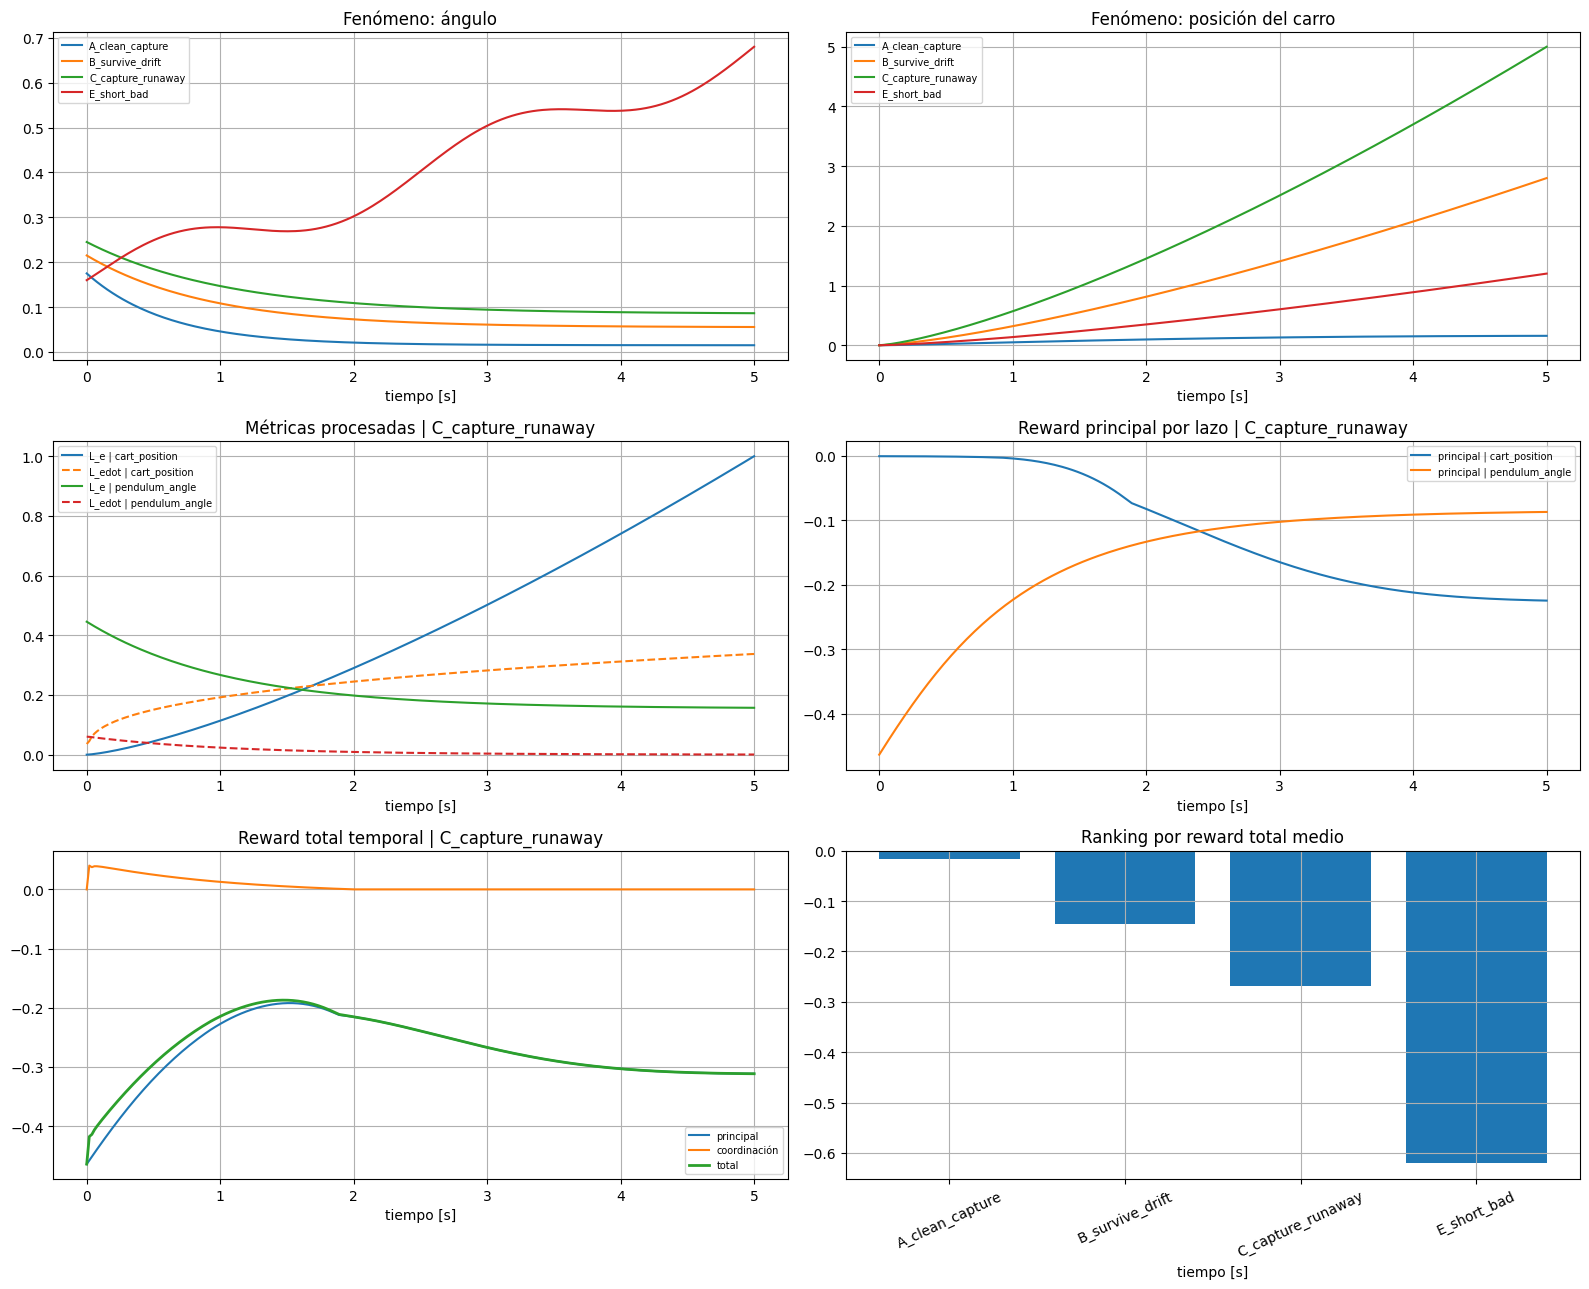

,behavior,global_mean,global_total,coordination_mean
0,A_clean_capture,-0.0168,-4.3656,0.0102
1,B_survive_drift,-0.1450,-37.6902,0.0077
2,C_capture_runaway,-0.2680,-69.6707,0.0061
3,E_short_bad,-0.6207,-161.3717,0.0005


In [16]:
SECTION_4_SELECTED_BEHAVIOR = "C_capture_runaway"

dashboard_loop_df, dashboard_global_df, dashboard_summary_df = plot_design_dashboard(
    behavior_profile_df,
    active_design_params,
    selected_behavior=SECTION_4_SELECTED_BEHAVIOR,
)


### Subcaja C: salida

Este bloque descompone el comportamiento seleccionado con más detalle.

Qué hace:
- grafica gates y contribuciones por término;
- permite ver qué parámetro está moviendo el reward.

Qué significan los parámetros:
- `gate_L_e`, `gate_L_edot`, `gate_L_u`: energía efectiva de cada término;
- `reward_*`: contribución tras aplicar compuerta.

Qué se debería buscar:
- que las compuertas se abran/cerren donde el fenómeno lo justifica;
- que una contribución no destruya el orden fenomenológico.

Cómo interpretar la salida:
- si el total se ve mal, aquí se identifica la perilla responsable.


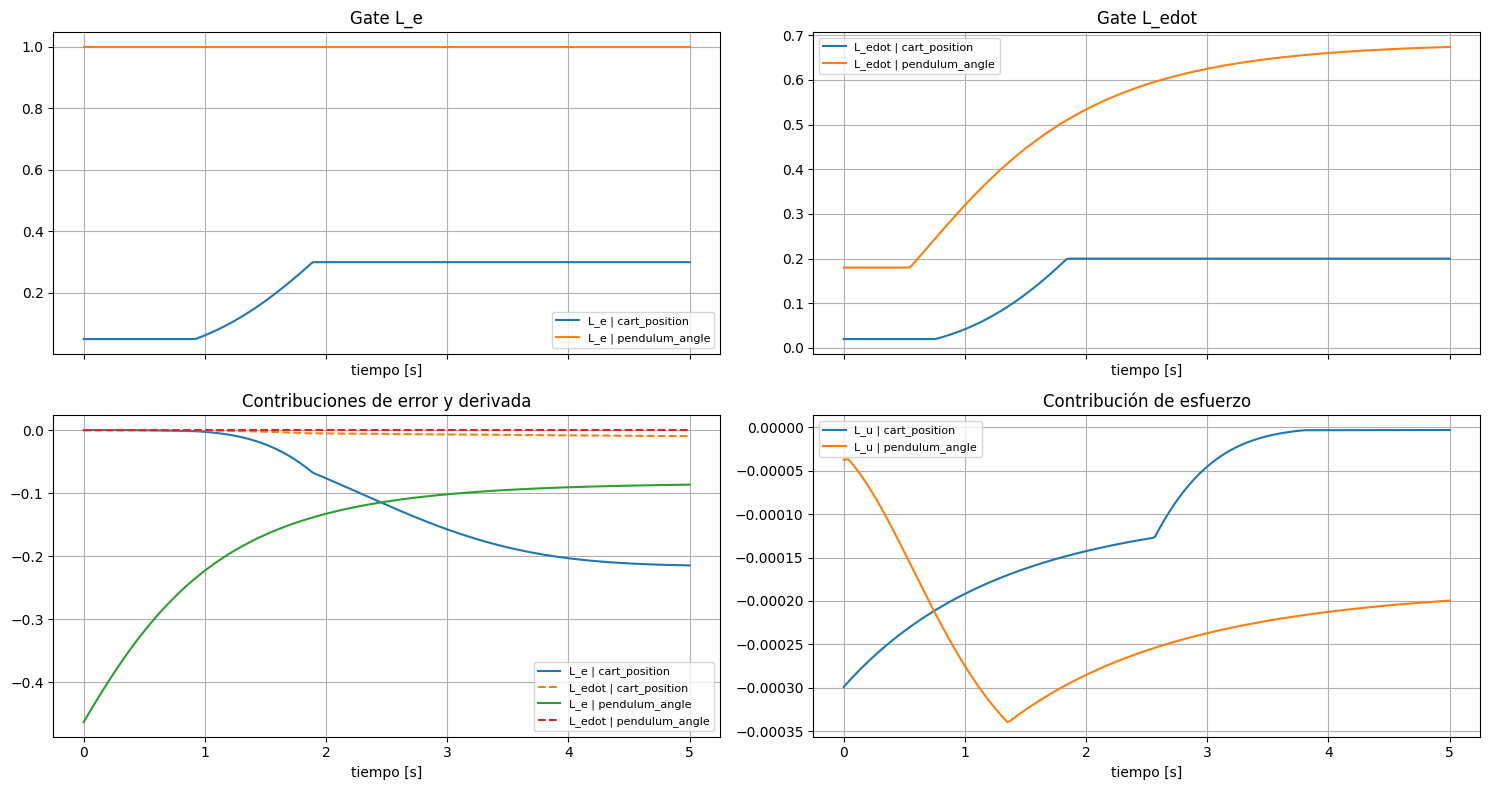

In [17]:
detail_df = dashboard_loop_df[dashboard_loop_df["behavior"] == SECTION_4_SELECTED_BEHAVIOR].copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

for loop, df in detail_df.groupby("loop"):
    axes[0, 0].plot(df["t"], df["gate_L_e"], label=f"L_e | {loop}")
    axes[0, 1].plot(df["t"], df["gate_L_edot"], label=f"L_edot | {loop}")
    axes[1, 0].plot(df["t"], df["reward_L_e"], label=f"L_e | {loop}")
    axes[1, 0].plot(df["t"], df["reward_L_edot"], linestyle="--", label=f"L_edot | {loop}")
    axes[1, 1].plot(df["t"], df["reward_L_u"], label=f"L_u | {loop}")

axes[0, 0].set_title("Gate L_e")
axes[0, 1].set_title("Gate L_edot")
axes[1, 0].set_title("Contribuciones de error y derivada")
axes[1, 1].set_title("Contribución de esfuerzo")

for ax in axes.ravel():
    ax.set_xlabel("tiempo [s]")
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Sección 5 - Superficies de respuesta integradas

### Subcaja A: universo disponible

Este bloque construye superficies donde se ven juntos lazos y coordinación.

Qué hace:
- varía simultáneamente el error del péndulo y el error del carro;
- mantiene derivadas y esfuerzo fijos;
- evalúa principal, coordinación proxy y reward total.

Qué significan los parámetros:
- `SECTION_5_PREV_POTENTIAL`: potencial anterior usado para calcular progreso;
- `SECTION_5_FIXED_*`: condiciones fijas de derivada y esfuerzo.

Qué se debería buscar:
- que la superficie premie reducir ambos errores;
- que el carro no domine antes de capturar el péndulo;
- que la coordinación tenga efecto localizable.

Cómo interpretar la salida:
- esta superficie responde: “si el sistema está aquí, ¿qué reward total ve?”.


In [18]:
SECTION_5_POINTS = 85
SECTION_5_FIXED_EDOT = 0.08
SECTION_5_FIXED_U = 0.05
SECTION_5_PREV_POTENTIAL = 0.55

def evaluate_static_total_surface(params, n_points=80, fixed_edot=0.08, fixed_u=0.05, prev_potential=0.55):
    p = np.linspace(0.0, 1.0, n_points)
    c = np.linspace(0.0, 1.0, n_points)
    P, C = np.meshgrid(p, c)
    rows = []

    for pend_e, cart_e in zip(P.ravel(), C.ravel()):
        local_profile = pd.DataFrame([
            {"behavior": "surface", "t": 0.0, "loop": "pendulum_angle", "L_e": pend_e, "L_edot": fixed_edot, "L_u": fixed_u},
            {"behavior": "surface", "t": 0.0, "loop": "cart_position", "L_e": cart_e, "L_edot": fixed_edot, "L_u": fixed_u},
        ])
        loop_eval, _ = evaluate_reward_design(local_profile, params)
        principal = loop_eval["principal_loop_reward"].sum()

        phi = 0.0
        for feature, per_loop in params["coordination"]["potential_weights"].items():
            for loop, weight in per_loop.items():
                value = pend_e if (feature == "L_e" and loop == "pendulum_angle") else None
                if feature == "L_e" and loop == "cart_position":
                    value = cart_e
                if feature == "L_edot":
                    value = fixed_edot
                phi += weight * value

        progress = np.clip(prev_potential - phi, 0.0, params["coordination"]["progress_clip_max"])
        coordination = params["coordination"]["global_weight"] * progress
        rows.append({
            "L_e_pendulum_angle": pend_e,
            "L_e_cart_position": cart_e,
            "principal_reward": principal,
            "coordination_reward": coordination,
            "global_reward": principal + coordination,
            "coordination_potential": phi,
        })

    return pd.DataFrame(rows), P, C


surface_df, SURF_P, SURF_C = evaluate_static_total_surface(
    active_design_params,
    n_points=SECTION_5_POINTS,
    fixed_edot=SECTION_5_FIXED_EDOT,
    fixed_u=SECTION_5_FIXED_U,
    prev_potential=SECTION_5_PREV_POTENTIAL,
)

display(surface_df.head())


,L_e_pendulum_angle,L_e_cart_position,principal_reward,coordination_reward,global_reward,coordination_potential
0,0.000000,0.0,-0.003013,0.48,0.476987,0.020800
1,0.011905,0.0,-0.003543,0.48,0.476457,0.029133
2,0.023810,0.0,-0.005132,0.48,0.474868,0.037467
3,0.035714,0.0,-0.007773,0.48,0.472227,0.045800
4,0.047619,0.0,-0.011453,0.48,0.468547,0.054133


### Subcaja B: configuración analítica

Este bloque prepara matrices para graficar.

Qué hace:
- convierte `surface_df` en matrices;
- permite elegir qué superficie mirar.

Qué significan los parámetros:
- `SECTION_5_SURFACE_TARGET`: `global_reward`, `principal_reward`, `coordination_reward` o `coordination_potential`.

Qué se debería buscar:
- diferencias entre principal y total;
- dónde la coordinación cambia la decisión.

Cómo interpretar la salida:
- si la coordinación mueve todo uniformemente, no está discriminando progreso útil.


In [19]:
SECTION_5_SURFACE_TARGET = "global_reward"

SURF_Z = surface_df[SECTION_5_SURFACE_TARGET].to_numpy().reshape(SURF_P.shape)
PRINCIPAL_Z = surface_df["principal_reward"].to_numpy().reshape(SURF_P.shape)
COORD_Z = surface_df["coordination_reward"].to_numpy().reshape(SURF_P.shape)


### Subcaja C: salida

Este bloque dibuja superficies de principal, coordinación y total.

Qué hace:
- muestra tres mapas comparables;
- permite ver si el total responde al fenómeno conjunto.

Qué se debería buscar:
- principal local coherente;
- coordinación visible solo donde hay progreso;
- total que preserve la jerarquía de estados.

Cómo interpretar la salida:
- una superficie total bien calibrada no aplasta la captura parcial ni ignora el carro.


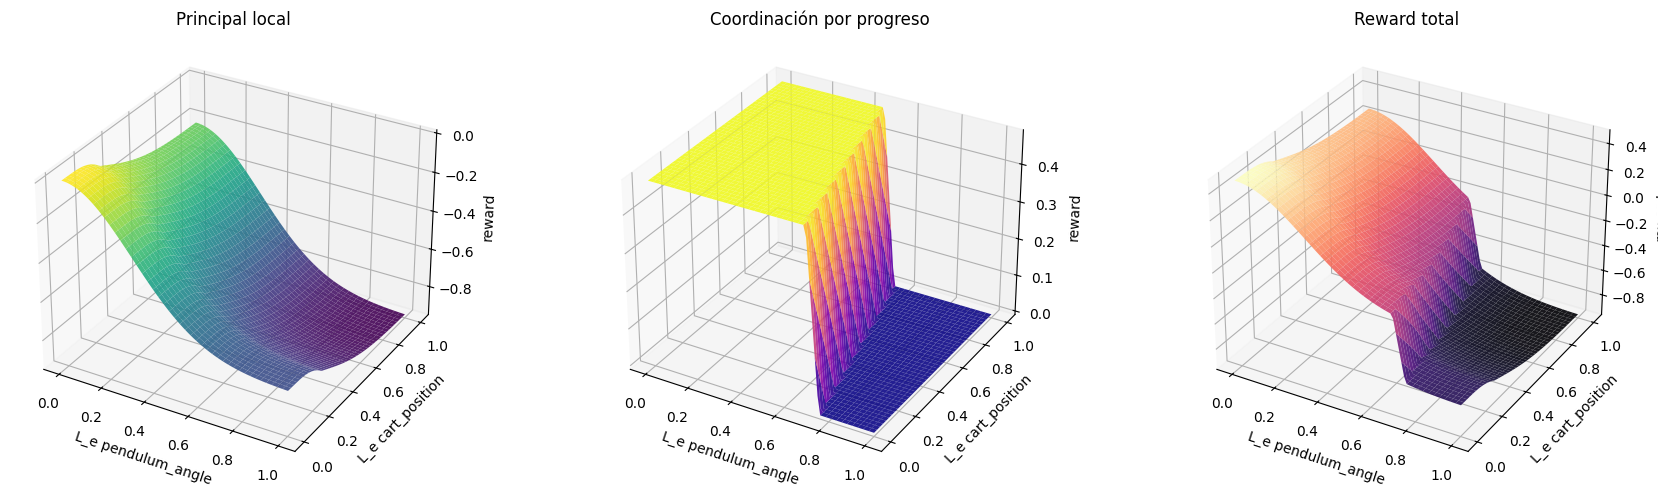

In [20]:
fig = plt.figure(figsize=(18, 5))

for i, (title, Z, cmap) in enumerate([
    ("Principal local", PRINCIPAL_Z, "viridis"),
    ("Coordinación por progreso", COORD_Z, "plasma"),
    ("Reward total", SURF_Z, "magma"),
], start=1):
    ax = fig.add_subplot(1, 3, i, projection="3d")
    ax.plot_surface(SURF_P, SURF_C, Z, cmap=cmap, linewidth=0, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("L_e pendulum_angle")
    ax.set_ylabel("L_e cart_position")
    ax.set_zlabel("reward")

plt.tight_layout()
plt.show()


## Sección 6 - Barrido fenomenológico y matriz de decisión

### Subcaja A: universo disponible

Este bloque cambia el fenómeno, no solo los parámetros.

Qué hace:
- barre captura angular y deriva del carro;
- recalcula perfiles sintéticos;
- evalúa márgenes de decisión.

Qué significan los parámetros:
- `capture_multiplier`: hace más fácil o difícil capturar;
- `cart_drift_multiplier`: aumenta o reduce deriva;
- los márgenes comparan clases de comportamiento.

Qué se debería buscar:
- parámetros robustos frente a variaciones del fenómeno;
- evitar que el diseño funcione solo en un perfil sintético puntual.

Cómo interpretar la salida:
- un buen diseño mantiene `A > B > C > E` en una región amplia.


In [21]:
SECTION_6_CAPTURE_MULTIPLIERS = [0.75, 1.00, 1.25]
SECTION_6_CART_DRIFT_MULTIPLIERS = [0.75, 1.00, 1.25]
SECTION_6_CANDIDATES = list(CANDIDATE_OVERRIDES.keys())

def summarize_design_order(profile_df, params):
    _, global_df = evaluate_reward_design(profile_df, params)
    score = global_df.groupby("behavior")["global_reward"].mean()
    return {
        "A": score.get("A_clean_capture", np.nan),
        "B": score.get("B_survive_drift", np.nan),
        "C": score.get("C_capture_runaway", np.nan),
        "E": score.get("E_short_bad", np.nan),
        "margin_A_over_B": score.get("A_clean_capture", np.nan) - score.get("B_survive_drift", np.nan),
        "margin_A_over_C": score.get("A_clean_capture", np.nan) - score.get("C_capture_runaway", np.nan),
        "margin_C_over_E": score.get("C_capture_runaway", np.nan) - score.get("E_short_bad", np.nan),
    }

sweep_rows = []
for candidate in SECTION_6_CANDIDATES:
    params = build_reward_params(candidate)
    for capture_multiplier in SECTION_6_CAPTURE_MULTIPLIERS:
        for cart_drift_multiplier in SECTION_6_CART_DRIFT_MULTIPLIERS:
            local_profiles = deepcopy(PROFILE_PARAMS)
            for behavior in local_profiles:
                if behavior != "E_short_bad":
                    local_profiles[behavior]["capture_rate"] *= capture_multiplier
                if behavior in ["B_survive_drift", "C_capture_runaway"]:
                    local_profiles[behavior]["cart_drift"] *= cart_drift_multiplier
            local_profile_df = build_behavior_profiles(TIME_CONFIG, local_profiles, PHYSICAL_SCALES)
            row = summarize_design_order(local_profile_df, params)
            row.update({
                "candidate": candidate,
                "capture_multiplier": capture_multiplier,
                "cart_drift_multiplier": cart_drift_multiplier,
            })
            sweep_rows.append(row)

sweep_decision_df = pd.DataFrame(sweep_rows)
display(sweep_decision_df.head())


,A,B,C,E,margin_A_over_B,margin_A_over_C,margin_C_over_E,candidate,capture_multiplier,cart_drift_multiplier
0,-0.024762,-0.139720,-0.264927,-0.62066,0.114957,0.240165,0.355733,base_soft_recenter,0.75,0.75
1,-0.024762,-0.163391,-0.292223,-0.62066,0.138629,0.267461,0.328437,base_soft_recenter,0.75,1.00
2,-0.024762,-0.184463,-0.311570,-0.62066,0.159701,0.286807,0.309091,base_soft_recenter,0.75,1.25
3,-0.016791,-0.121377,-0.240756,-0.62066,0.104586,0.223965,0.379905,base_soft_recenter,1.00,0.75
4,-0.016791,-0.144962,-0.267964,-0.62066,0.128172,0.251174,0.352696,base_soft_recenter,1.00,1.00


### Subcaja B: configuración analítica

Este bloque define umbrales de aceptación.

Qué hace:
- convierte márgenes en criterios;
- calcula cuántos escenarios pasan por candidato.

Qué significan los parámetros:
- `MIN_MARGIN_A_OVER_B`: captura limpia debe superar supervivencia con deriva;
- `MIN_MARGIN_A_OVER_C`: captura limpia debe superar captura con escape;
- `MIN_MARGIN_C_OVER_E`: captura parcial debe superar fallo corto.

Qué se debería buscar:
- no solo pasar el caso base;
- pasar variaciones fenomenológicas razonables.

Cómo interpretar la salida:
- candidatos frágiles son mala señal aunque se vean bien en un dashboard.


In [22]:
MIN_MARGIN_A_OVER_B = 0.02
MIN_MARGIN_A_OVER_C = 0.05
MIN_MARGIN_C_OVER_E = 0.25

sweep_decision_df["pass_A_over_B"] = sweep_decision_df["margin_A_over_B"] >= MIN_MARGIN_A_OVER_B
sweep_decision_df["pass_A_over_C"] = sweep_decision_df["margin_A_over_C"] >= MIN_MARGIN_A_OVER_C
sweep_decision_df["pass_C_over_E"] = sweep_decision_df["margin_C_over_E"] >= MIN_MARGIN_C_OVER_E
sweep_decision_df["passes_all"] = sweep_decision_df[["pass_A_over_B", "pass_A_over_C", "pass_C_over_E"]].all(axis=1)

candidate_robustness_df = (
    sweep_decision_df
    .groupby("candidate")
    .agg(
        scenarios=("passes_all", "count"),
        pass_rate=("passes_all", "mean"),
        min_A_over_B=("margin_A_over_B", "min"),
        min_A_over_C=("margin_A_over_C", "min"),
        min_C_over_E=("margin_C_over_E", "min"),
    )
    .reset_index()
)

display(candidate_robustness_df.round(4))


,candidate,scenarios,pass_rate,min_A_over_B,min_A_over_C,min_C_over_E
0,base_soft_recenter,9,1.0,0.0981,0.2135,0.3091
1,less_effort_penalty,9,1.0,0.0981,0.2135,0.3089
2,more_cart_recenter,9,1.0,0.1017,0.2243,0.2919
3,strong_coordination,9,1.0,0.0987,0.2146,0.3105


### Subcaja C: salida

Este bloque grafica robustez de candidatos.

Qué hace:
- muestra tasa de aprobación;
- muestra márgenes mínimos.

Qué se debería buscar:
- alta tasa de aprobación;
- margen `C > E` amplio;
- margen `A > C` suficiente, pero no a costa de destruir `C`.

Cómo interpretar la salida:
- esta es la primera matriz de decisión antes de pasar a simulaciones reales.


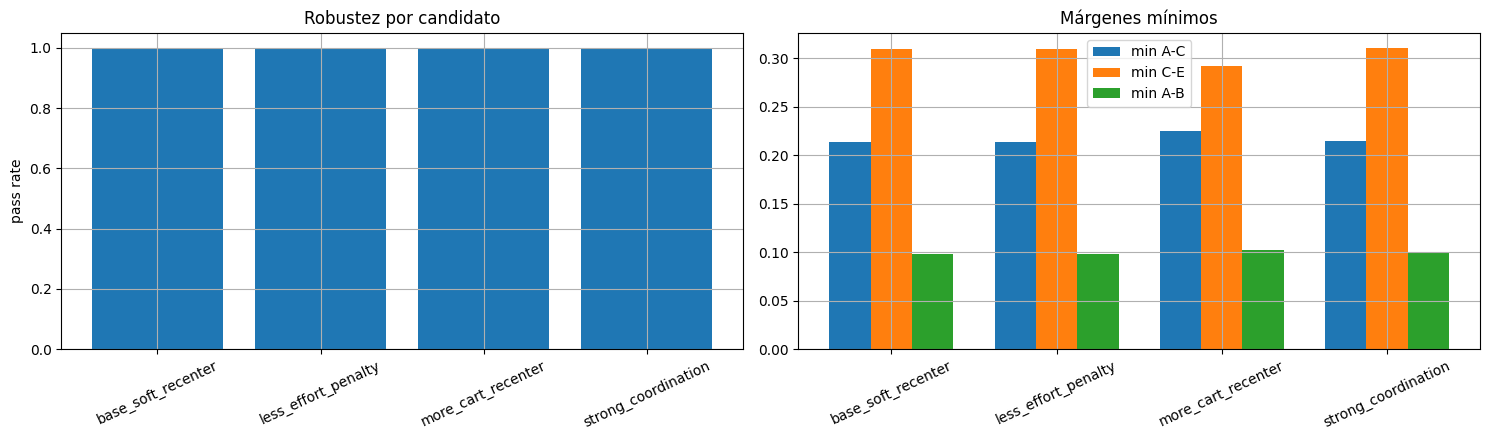

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].bar(candidate_robustness_df["candidate"], candidate_robustness_df["pass_rate"])
axes[0].set_title("Robustez por candidato")
axes[0].set_ylabel("pass rate")
axes[0].tick_params(axis="x", rotation=25)

x = np.arange(len(candidate_robustness_df))
axes[1].bar(x - 0.25, candidate_robustness_df["min_A_over_C"], width=0.25, label="min A-C")
axes[1].bar(x, candidate_robustness_df["min_C_over_E"], width=0.25, label="min C-E")
axes[1].bar(x + 0.25, candidate_robustness_df["min_A_over_B"], width=0.25, label="min A-B")
axes[1].set_xticks(x)
axes[1].set_xticklabels(candidate_robustness_df["candidate"], rotation=25)
axes[1].set_title("Márgenes mínimos")
axes[1].legend()

plt.tight_layout()
plt.show()


## Sección 7 - Panel interactivo opcional

### Subcaja A: universo disponible

Este bloque intenta activar `ipywidgets`.

Qué hace:
- si `ipywidgets` está disponible, crea sliders;
- si no está disponible, muestra instrucciones para usar el modo manual.

Qué significan los parámetros:
- los sliders modifican pesos, compuertas y coordinación;
- todos llaman al mismo dashboard de la Sección 4.

Qué se debería buscar:
- mover una perilla y mirar fenómeno + reward total juntos.

Cómo interpretar la salida:
- si no ves widgets, edita `MANUAL_REWARD_OVERRIDE` en la Sección 2.


In [24]:
try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False

print("WIDGETS_AVAILABLE =", WIDGETS_AVAILABLE)


WIDGETS_AVAILABLE = True


### Subcaja B: configuración analítica

Este bloque define el panel de sliders.

Qué hace:
- vincula sliders a parámetros críticos;
- reconstruye el objeto de reward en cada cambio;
- actualiza el dashboard.

Qué significan los parámetros:
- `cart_L_e_max`: cuánto se abre el castigo de error del carro;
- `cart_L_edot_max`: cuánto se abre el castigo derivativo del carro;
- `L_u_weight`: castigo de esfuerzo;
- `coord_weight`: energía coordinativa.

Qué se debería buscar:
- subir carro solo hasta que `A > C` sea claro sin destruir `C > E`;
- no usar coordinación para tapar errores.

Cómo interpretar la salida:
- el panel debe leerse con la matriz de decisión, no solo con una curva bonita.


In [25]:
def params_from_slider_values(cart_L_e_max=0.30, cart_L_edot_max=0.20, L_u_weight=0.035, coord_weight=12.0):
    override = {
        "features": {"L_u": {"weight": L_u_weight}},
        "gates": {
            "L_e": {"cart_position": {"max_factor": cart_L_e_max}},
            "L_edot": {"cart_position": {"max_factor": cart_L_edot_max}},
        },
        "coordination": {"global_weight": coord_weight},
    }
    return build_reward_params("base_soft_recenter", override)


def interactive_dashboard(cart_L_e_max=0.30, cart_L_edot_max=0.20, L_u_weight=0.035, coord_weight=12.0, behavior="C_capture_runaway"):
    params = params_from_slider_values(cart_L_e_max, cart_L_edot_max, L_u_weight, coord_weight)
    plot_design_dashboard(behavior_profile_df, params, selected_behavior=behavior)


### Subcaja C: salida

Este bloque muestra el panel si el entorno lo permite.

Qué hace:
- renderiza controles interactivos;
- usa fallback textual si no hay `ipywidgets`.

Qué se debería buscar:
- experimentación rápida con parámetros;
- comparar visualmente antes de llevar valores a config.

Cómo interpretar la salida:
- si el widget no aparece, el notebook sigue siendo funcional en modo manual.


In [26]:
if WIDGETS_AVAILABLE:
    ui = widgets.VBox([
        widgets.FloatSlider(value=0.30, min=0.20, max=0.45, step=0.01, description="cart L_e max"),
        widgets.FloatSlider(value=0.20, min=0.12, max=0.32, step=0.01, description="cart L_edot max"),
        widgets.FloatSlider(value=0.035, min=0.00, max=0.08, step=0.005, description="L_u weight"),
        widgets.FloatSlider(value=12.0, min=4.0, max=20.0, step=1.0, description="coord weight"),
        widgets.Dropdown(options=list(PROFILE_PARAMS.keys()), value="C_capture_runaway", description="behavior"),
    ])

    out = widgets.interactive_output(
        interactive_dashboard,
        {
            "cart_L_e_max": ui.children[0],
            "cart_L_edot_max": ui.children[1],
            "L_u_weight": ui.children[2],
            "coord_weight": ui.children[3],
            "behavior": ui.children[4],
        },
    )
    display(ui, out)
else:
    display(Markdown(
        "No hay `ipywidgets` en este entorno. Usa el modo manual: edita `MANUAL_REWARD_OVERRIDE` "
        "en la Sección 2 y reejecuta desde la Sección 3."
    ))


Output()

## Sección 8 - Ficha de propuesta y lectura final

### Subcaja A: universo disponible

Este bloque toma un candidato y lo convierte en ficha.

Qué hace:
- selecciona candidato;
- empaqueta principal, compuertas y coordinación;
- conserva el contrato de diseño.

Qué significan los parámetros:
- `SECTION_8_SELECTED_CANDIDATE`: propuesta que quieres documentar.

Qué se debería buscar:
- valores trazables;
- cambios mínimos y explicables.

Cómo interpretar la salida:
- esta ficha sirve para discusión antes de tocar un YAML real.


In [27]:
SECTION_8_SELECTED_CANDIDATE = ACTIVE_CANDIDATE
proposal_params = build_reward_params(SECTION_8_SELECTED_CANDIDATE, MANUAL_REWARD_OVERRIDE)

proposal_card = {
    "candidate": SECTION_8_SELECTED_CANDIDATE,
    "manual_override": MANUAL_REWARD_OVERRIDE,
    "reward_params": proposal_params,
    "design_contract": {
        "principal_reward": "local por lazo",
        "feature_gates": "source_feature del mismo lazo",
        "coordination_reward": "único bloque multi-lazo por diferencia de potencial",
    },
}

print(json.dumps(proposal_card, indent=2, ensure_ascii=False))


{
  "candidate": "base_soft_recenter",
  "manual_override": {},
  "reward_params": {
    "features": {
      "L_e": {
        "weight": 0.72,
        "scaled": 5.2,
        "setpoint": 0.0
      },
      "L_edot": {
        "weight": 0.22,
        "scaled": 2.2,
        "setpoint": 0.0
      },
      "L_I": {
        "weight": 0.0,
        "scaled": 1.0,
        "setpoint": 0.0
      },
      "L_u": {
        "weight": 0.035,
        "scaled": 0.7,
        "setpoint": 0.0
      }
    },
    "gates": {
      "L_e": {
        "pendulum_angle": {
          "source_feature": "L_e",
          "scaled": 1.0,
          "min_factor": 1.0,
          "max_factor": 1.0,
          "invert": false
        },
        "cart_position": {
          "source_feature": "L_e",
          "scaled": 0.45,
          "min_factor": 0.05,
          "max_factor": 0.3,
          "invert": true
        }
      },
      "L_edot": {
        "pendulum_angle": {
          "source_feature": "L_e",
          "scaled": 0.2

### Subcaja B: configuración analítica

Este bloque genera una lectura automática simple.

Qué hace:
- revisa la matriz de robustez;
- sugiere qué mirar si falla un criterio.

Qué significan los parámetros:
- usa `candidate_robustness_df` y `sweep_decision_df`.

Qué se debería buscar:
- diagnóstico accionable, no solo números.

Cómo interpretar la salida:
- si un criterio falla, vuelve a la sección indicada.


In [28]:
diagnosis_rows = []
for _, row in candidate_robustness_df.iterrows():
    candidate = row["candidate"]
    if row["pass_rate"] == 1.0:
        diagnosis = "candidato consistente en el barrido sintético"
        next_step = "probar con datos reales o simulación"
    elif row["min_C_over_E"] < MIN_MARGIN_C_OVER_E:
        diagnosis = "captura parcial queda demasiado cerca del fallo corto"
        next_step = "reducir castigo de carro/esfuerzo o revisar compuertas"
    elif row["min_A_over_C"] < MIN_MARGIN_A_OVER_C:
        diagnosis = "captura limpia no supera suficiente a captura con escape"
        next_step = "subir suavemente compuerta del carro o potencial del carro"
    else:
        diagnosis = "criterio mixto, revisar dashboard"
        next_step = "inspeccionar Sección 4 y Sección 5"
    diagnosis_rows.append({"candidate": candidate, "diagnosis": diagnosis, "next_step": next_step})

diagnosis_df = pd.DataFrame(diagnosis_rows)
display(diagnosis_df)


,candidate,diagnosis,next_step
0,base_soft_recenter,candidato consistente en el barrido sintético,probar con datos reales o simulación
1,less_effort_penalty,candidato consistente en el barrido sintético,probar con datos reales o simulación
2,more_cart_recenter,candidato consistente en el barrido sintético,probar con datos reales o simulación
3,strong_coordination,candidato consistente en el barrido sintético,probar con datos reales o simulación


### Subcaja C: salida

Este bloque cierra el flujo de diseño.

Qué hace:
- resume qué salida produjo cada sección;
- indica cómo usar el notebook cuando una corrida real falla.

Qué se debería buscar:
- no reaccionar con cambios grandes;
- identificar qué criterio se rompió.

Cómo interpretar la salida:
- este notebook debe ser el paso previo a editar parámetros reales.


In [29]:
FINAL_WORKFLOW = pd.DataFrame([
    {"when": "quiero cambiar setpoint o sistema", "go_to": "Sección 1", "reason": "redefinir fenómeno y escalas"},
    {"when": "el reward no distingue estados", "go_to": "Sección 2 y 5", "reason": "curvas, compuertas y superficies"},
    {"when": "el carro se escapa", "go_to": "Sección 4 y 6", "reason": "ver si subir carro destruye captura parcial"},
    {"when": "la coordinación desaparece", "go_to": "Sección 3 y 5", "reason": "revisar potencial y progreso"},
    {"when": "un candidato parece bueno", "go_to": "Sección 6 y 8", "reason": "validar robustez y documentar propuesta"},
])

display(FINAL_WORKFLOW)


,when,go_to,reason
0,quiero cambiar setpoint o sistema,Sección 1,redefinir fenómeno y escalas
1,el reward no distingue estados,Sección 2 y 5,"curvas, compuertas y superficies"
2,el carro se escapa,Sección 4 y 6,ver si subir carro destruye captura parcial
3,la coordinación desaparece,Sección 3 y 5,revisar potencial y progreso
4,un candidato parece bueno,Sección 6 y 8,validar robustez y documentar propuesta
